## Imports

In [7]:
import sys
sys.path.append('../src')  

from nuscenes.nuscenes import NuScenes
import numpy as np
import matplotlib.pyplot as plt
from kalman_filter import KalmanFilter

nusc = NuScenes(version='v1.0-mini', dataroot=r'C:\Users\dell\Desktop\SENTINEL\data\data_Nuscenes', verbose=False)
print("✅ Loaded nuScenes")


✅ Loaded nuScenes


# Get vehicle trajectory

In [8]:

def get_vehicle_trajectory(nusc, instance_token, scene):
    trajectory = []
    sample_token = scene['first_sample_token']
    
    while sample_token:
        sample = nusc.get('sample', sample_token)
        
        for ann_token in sample['anns']:
            ann = nusc.get('sample_annotation', ann_token)
            
            if ann['instance_token'] == instance_token:
                trajectory.append({
                    'timestamp': sample['timestamp'] / 1e6,  # Convert to seconds
                    'position': ann['translation'][:2],  # [x, y]
                })
                break
        
        sample_token = sample['next']
    
    return trajectory

# Get first scene and first vehicle
my_scene = nusc.scene[0]
first_sample = nusc.get('sample', my_scene['first_sample_token'])
first_ann_token = first_sample['anns'][0]
first_ann = nusc.get('sample_annotation', first_ann_token)
instance_token = first_ann['instance_token']

# Extract trajectory
trajectory = get_vehicle_trajectory(nusc, instance_token, my_scene)
print(f"✅ Extracted trajectory: {len(trajectory)} points")
 

✅ Extracted trajectory: 39 points


# Add artificial noise to simulate sensor uncertainty

In [9]:

def add_sensor_noise(trajectory, noise_std=5.0):
    """Add Gaussian noise to simulate real sensor measurements"""
    noisy_measurements = []
    
    for point in trajectory:
        noisy_pos = point['position'] + np.random.randn(2) * noise_std
        noisy_measurements.append({
            'timestamp': point['timestamp'],
            'position': noisy_pos,
            'true_position': point['position']
        })
    
    return noisy_measurements

# Create noisy measurements
noisy_data = add_sensor_noise(trajectory, noise_std=5.0)
print(f"✅ Added noise to measurements")

✅ Added noise to measurements


# Running Kalman Filter

In [10]:
def track_with_kalman(measurements, dt=0.5):
    """Track object using Kalman filter"""
    
    kf = KalmanFilter(dt=dt, process_noise=1.0, measurement_noise=5.0)
    
    # Initialize with first measurement
    first_meas = measurements[0]['position']
    kf.x = np.array([[first_meas[0]], [first_meas[1]], [0], [0]])
    
    estimates = []
    
    for meas in measurements:
        # Predict
        kf.predict()
        
        # Update with measurement
        kf.update(meas['position'])
        
        # Store estimate
        estimates.append({
            'timestamp': meas['timestamp'],
            'position': kf.get_position(),
            'velocity': kf.get_velocity()
        })
    
    return estimates
estimates = track_with_kalman(noisy_data, dt=0.5)
print(f"✅ Kalman filter tracking complete")


✅ Kalman filter tracking complete


# Visualizing results

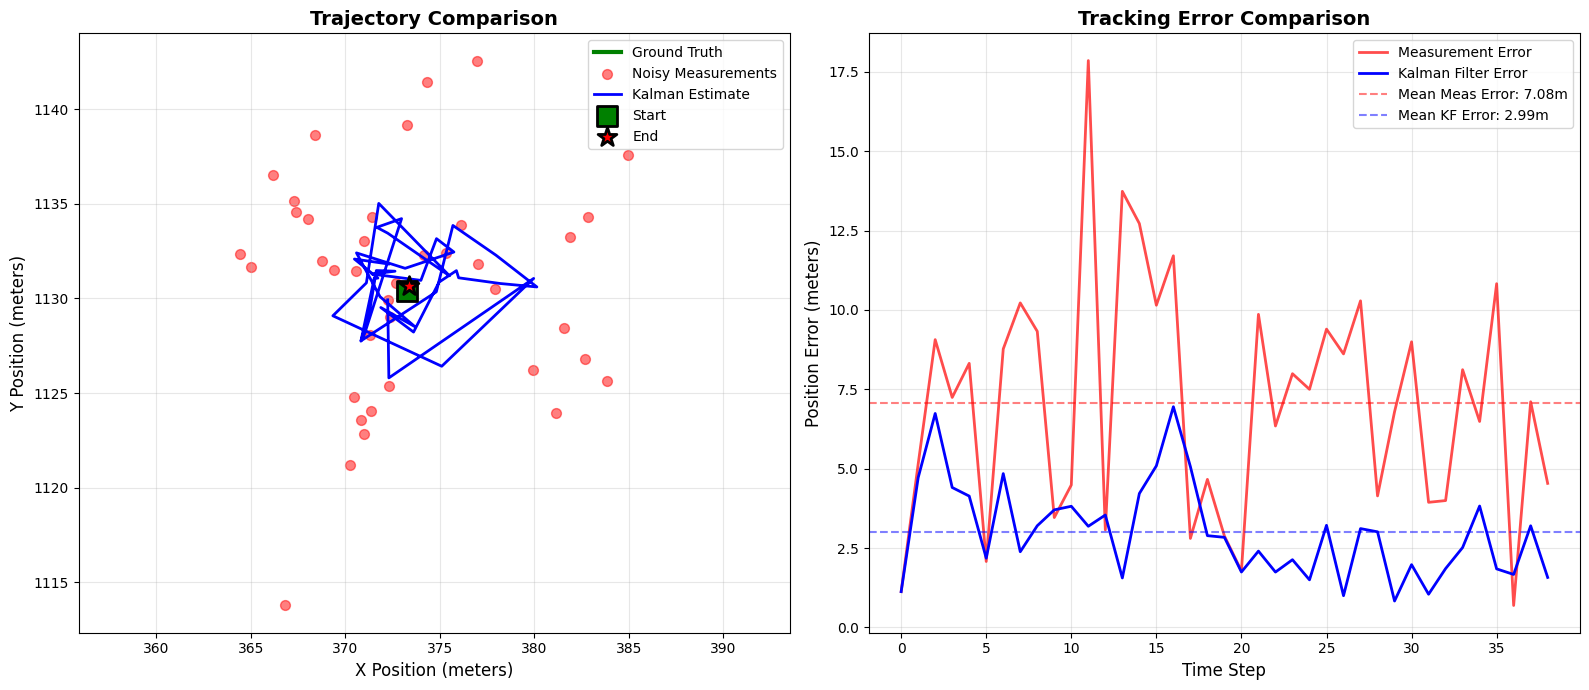


TRACKING PERFORMANCE METRICS
Mean Measurement Error:  7.08 meters
Mean Kalman Filter Error: 2.99 meters
Error Reduction:          57.7%
Max Measurement Error:    17.85 meters
Max Kalman Filter Error:  6.95 meters


In [11]:
def plot_tracking_results(ground_truth, noisy_measurements, kalman_estimates):
    """Compare ground truth, noisy measurements, and Kalman estimates"""
    
    # Extract data
    gt_pos = np.array([t['true_position'] for t in noisy_measurements])
    noisy_pos = np.array([m['position'] for m in noisy_measurements])
    est_pos = np.array([e['position'] for e in kalman_estimates])
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot 1: Trajectory comparison
    ax1.plot(gt_pos[:, 0], gt_pos[:, 1], 'g-', linewidth=3, label='Ground Truth', zorder=3)
    ax1.scatter(noisy_pos[:, 0], noisy_pos[:, 1], c='red', s=50, alpha=0.5, 
                label='Noisy Measurements', zorder=1)
    ax1.plot(est_pos[:, 0], est_pos[:, 1], 'b-', linewidth=2, label='Kalman Estimate', zorder=2)
    
    ax1.scatter(gt_pos[0, 0], gt_pos[0, 1], c='green', s=200, marker='s', 
                edgecolor='black', linewidth=2, label='Start', zorder=4)
    ax1.scatter(gt_pos[-1, 0], gt_pos[-1, 1], c='red', s=200, marker='*', 
                edgecolor='black', linewidth=2, label='End', zorder=4)
    
    ax1.set_xlabel('X Position (meters)', fontsize=12)
    ax1.set_ylabel('Y Position (meters)', fontsize=12)
    ax1.set_title('Trajectory Comparison', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.axis('equal')
    
    # Plot 2: Error over time
    gt_error = np.linalg.norm(noisy_pos - gt_pos, axis=1)
    kf_error = np.linalg.norm(est_pos - gt_pos, axis=1)
    
    time_steps = np.arange(len(gt_error))
    
    ax2.plot(time_steps, gt_error, 'r-', linewidth=2, label='Measurement Error', alpha=0.7)
    ax2.plot(time_steps, kf_error, 'b-', linewidth=2, label='Kalman Filter Error')
    ax2.axhline(y=np.mean(gt_error), color='r', linestyle='--', alpha=0.5, 
                label=f'Mean Meas Error: {np.mean(gt_error):.2f}m')
    ax2.axhline(y=np.mean(kf_error), color='b', linestyle='--', alpha=0.5, 
                label=f'Mean KF Error: {np.mean(kf_error):.2f}m')
    
    ax2.set_xlabel('Time Step', fontsize=12)
    ax2.set_ylabel('Position Error (meters)', fontsize=12)
    ax2.set_title('Tracking Error Comparison', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*60)
    print("TRACKING PERFORMANCE METRICS")
    print("="*60)
    print(f"Mean Measurement Error:  {np.mean(gt_error):.2f} meters")
    print(f"Mean Kalman Filter Error: {np.mean(kf_error):.2f} meters")
    print(f"Error Reduction:          {(1 - np.mean(kf_error)/np.mean(gt_error))*100:.1f}%")
    print(f"Max Measurement Error:    {np.max(gt_error):.2f} meters")
    print(f"Max Kalman Filter Error:  {np.max(kf_error):.2f} meters")
    print("="*60)

plot_tracking_results(trajectory, noisy_data, estimates)

# Animated tracking visualization

In [12]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def create_tracking_animation(ground_truth, measurements, estimates):
    """Create animated visualization of tracking"""
    
    gt_pos = np.array([t['true_position'] for t in measurements])
    meas_pos = np.array([m['position'] for m in measurements])
    est_pos = np.array([e['position'] for e in estimates])
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Initialize plots
    gt_line, = ax.plot([], [], 'g-', linewidth=3, label='Ground Truth')
    meas_scatter = ax.scatter([], [], c='red', s=100, alpha=0.5, label='Measurements')
    est_line, = ax.plot([], [], 'b-', linewidth=2, label='Kalman Estimate')
    current_pos = ax.scatter([], [], c='blue', s=200, marker='o', edgecolor='black', linewidth=2)
    
    # Set axis limits
    all_x = np.concatenate([gt_pos[:, 0], meas_pos[:, 0]])
    all_y = np.concatenate([gt_pos[:, 1], meas_pos[:, 1]])
    margin = 10
    ax.set_xlim(all_x.min() - margin, all_x.max() + margin)
    ax.set_ylim(all_y.min() - margin, all_y.max() + margin)
    
    ax.set_xlabel('X Position (meters)', fontsize=12)
    ax.set_ylabel('Y Position (meters)', fontsize=12)
    ax.set_title('Real-Time Tracking Visualization', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    def update(frame):
        # Update data
        gt_line.set_data(gt_pos[:frame+1, 0], gt_pos[:frame+1, 1])
        meas_scatter.set_offsets(meas_pos[:frame+1])
        est_line.set_data(est_pos[:frame+1, 0], est_pos[:frame+1, 1])
        current_pos.set_offsets([[est_pos[frame, 0], est_pos[frame, 1]]])
        
        return gt_line, meas_scatter, est_line, current_pos
    
    anim = FuncAnimation(fig, update, frames=len(gt_pos), 
                        interval=200, blit=True, repeat=True)
    
    plt.close() 
    return anim

# Create animation
anim = create_tracking_animation(trajectory, noisy_data, estimates)
HTML(anim.to_jshtml()) 

# Saving results

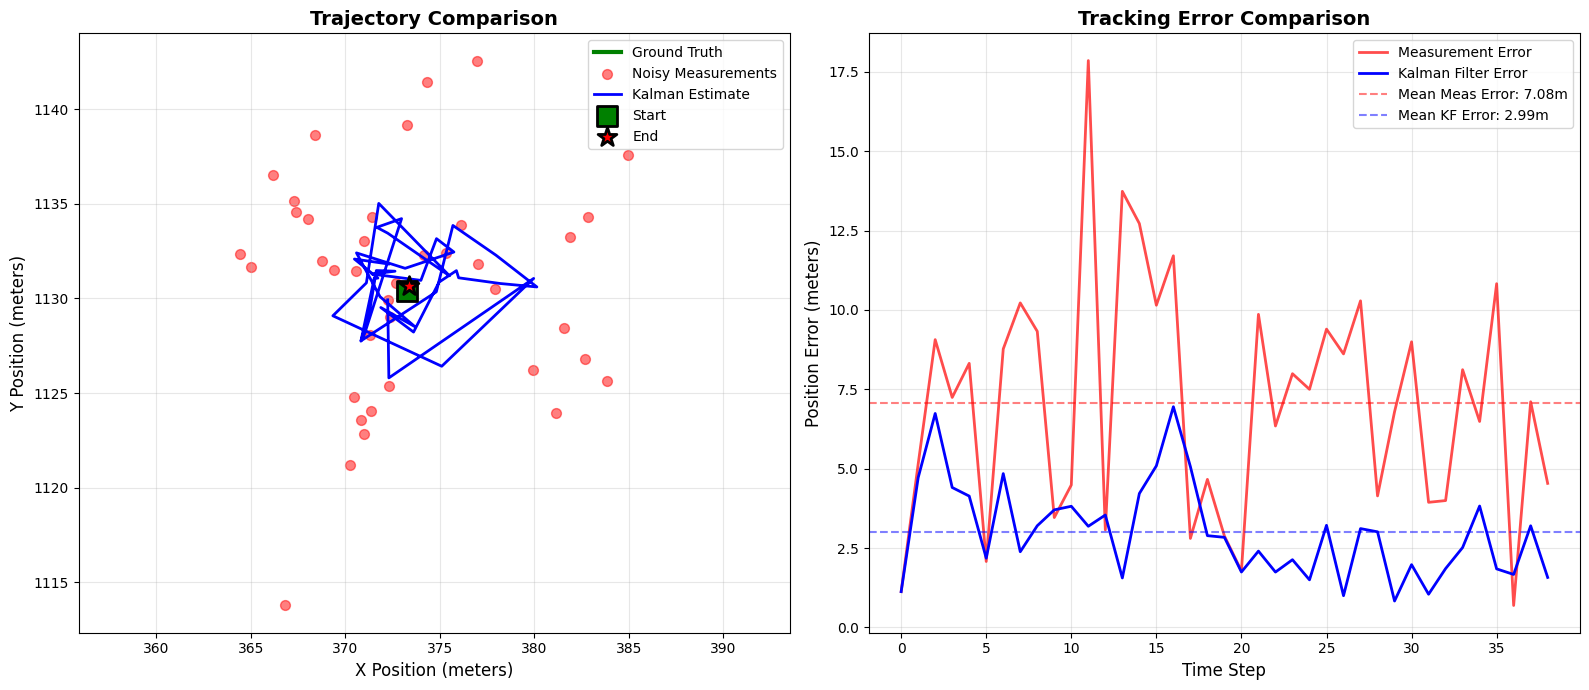


TRACKING PERFORMANCE METRICS
Mean Measurement Error:  7.08 meters
Mean Kalman Filter Error: 2.99 meters
Error Reduction:          57.7%
Max Measurement Error:    17.85 meters
Max Kalman Filter Error:  6.95 meters
Saved plot to C:\Users\dell\Desktop\SENTINEL\results\SOT_results/single_object_tracking.png
Saved animation to C:\Users\dell\Desktop\SENTINEL\results\SOT_results/tracking_animation.gif
Saved metrics to C:\Users\dell\Desktop\SENTINEL\results\SOT_results/metrics.txt


<Figure size 640x480 with 0 Axes>

In [15]:
import os
from datetime import datetime

# Create results directory
results_dir = r'C:\Users\dell\Desktop\SENTINEL\results\SOT_results'
os.makedirs(results_dir, exist_ok=True)

# Save static plot
plot_tracking_results(trajectory, noisy_data, estimates)
plt.savefig(f'{results_dir}/single_object_tracking.png', dpi=300, bbox_inches='tight')
print(f"Saved plot to {results_dir}/single_object_tracking.png")

# Save animation as GIF
anim.save(f'{results_dir}/tracking_animation.gif', writer='pillow', fps=5)
print(f"Saved animation to {results_dir}/tracking_animation.gif")

# Save metrics to text file
with open(f'{results_dir}/metrics.txt', 'w') as f:
    gt_pos = np.array([t['true_position'] for t in noisy_data])
    noisy_pos = np.array([m['position'] for m in noisy_data])
    est_pos = np.array([e['position'] for e in estimates])
    
    gt_error = np.linalg.norm(noisy_pos - gt_pos, axis=1)
    kf_error = np.linalg.norm(est_pos - gt_pos, axis=1)
    
    f.write("SENTINEL - Single Object Tracking Results\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write("="*60 + "\n\n")
    f.write(f"Number of samples: {len(trajectory)}\n")
    f.write(f"Mean measurement error: {np.mean(gt_error):.2f} m\n")
    f.write(f"Mean Kalman filter error: {np.mean(kf_error):.2f} m\n")
    f.write(f"Error reduction: {(1 - np.mean(kf_error)/np.mean(gt_error))*100:.1f}%\n")
    f.write(f"Standard deviation (meas): {np.std(gt_error):.2f} m\n")
    f.write(f"Standard deviation (KF): {np.std(kf_error):.2f} m\n")

print(f"Saved metrics to {results_dir}/metrics.txt")
